# Honest Forecasting Baselines

## Nigeria Food Procurement Intelligence Agent

This notebook evaluates transparent forecasting baselines for retail palm-oil prices. Geidam is used as the primary pilot market, while Budum is retained as a stress-test market because of its systematic reporting gaps and structural May 2022 price movement.

The objective is not to claim that food prices are perfectly predictable. The objective is to determine whether more advanced models can eventually outperform simple, reproducible and leakage-safe forecasting rules.

In [1]:
from pathlib import Path
import sys

using_project_environment = ".venv" in sys.executable.lower()

print("Using project environment:", using_project_environment)
print("Jupyter starting folder:", Path.cwd().name)

Using project environment: True
Jupyter starting folder: notebooks


# Honest Forecasting Baselines for Nigerian Retail Palm-Oil Prices

## Objective

This notebook evaluates transparent forecasting baselines for retail palm-oil prices in Geidam and Budum.

Geidam is the primary pilot series, while Budum is retained as a stress-test series because of its structural price movement and systematic reporting gaps.

The purpose is to establish how well simple forecasting methods perform before introducing more advanced statistical or machine-learning models.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Detect the repository root from Jupyter's starting folder.
current_folder = Path.cwd()

if current_folder.name == "notebooks":
    project_root = current_folder.parent
else:
    project_root = current_folder

data_path = (
    project_root
    / "data"
    / "raw"
    / "wfp_food_prices_nga.csv"
)

if not data_path.exists():
    raise FileNotFoundError(
        "The WFP food-price dataset was not found."
    )

food_prices = pd.read_csv(
    data_path,
    low_memory=False
)

food_prices["date"] = pd.to_datetime(
    food_prices["date"],
    errors="raise"
)

food_prices["price"] = pd.to_numeric(
    food_prices["price"],
    errors="raise"
)

food_prices["month"] = (
    food_prices["date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

print("Dataset successfully loaded.")
print("Dataset: data/raw/wfp_food_prices_nga.csv")
print("Rows:", len(food_prices))
print("Columns:", len(food_prices.columns))
print(
    "Date coverage:",
    food_prices["month"].min().date(),
    "to",
    food_prices["month"].max().date()
)

Dataset successfully loaded.
Dataset: data/raw/wfp_food_prices_nga.csv
Rows: 81534
Columns: 17
Date coverage: 2002-01-01 to 2026-07-01


## Selected Forecasting Series

Two like-for-like retail palm-oil series will be evaluated:

- **Geidam, Yobe:** primary forecasting pilot;
- **Budum, Borno:** stress-test series.

Both series use Nigerian naira per litre. Missing calendar months will be represented explicitly and will not be automatically imputed.

In [3]:
series_configuration = {
    "Geidam — primary": {
        "market_id": 2393,
        "expected_market": "Geidam"
    },
    "Budum — stress test": {
        "market_id": 2384,
        "expected_market": "Budum"
    }
}

def prepare_monthly_series(
    data,
    market_id,
    expected_market,
    series_label
):
    """Extract and calendar-align one retail palm-oil series."""

    selected = data[
        (data["market_id"] == market_id)
        & (data["commodity_id"] == 62)
        & (data["unit"] == "L")
        & (data["pricetype"] == "Retail")
    ][
        [
            "month",
            "admin1",
            "market",
            "price",
            "priceflag"
        ]
    ].copy()

    if selected.empty:
        raise ValueError(
            f"No observations found for {series_label}."
        )

    actual_markets = selected["market"].dropna().unique()

    if expected_market not in actual_markets:
        raise ValueError(
            f"Market ID {market_id} does not match "
            f"{expected_market}."
        )

    if selected["month"].duplicated().any():
        raise ValueError(
            f"Duplicate monthly observations found for "
            f"{series_label}."
        )

    selected = selected.sort_values("month")

    complete_calendar = pd.date_range(
        selected["month"].min(),
        selected["month"].max(),
        freq="MS"
    )

    monthly = (
        selected
        .set_index("month")
        .reindex(complete_calendar)
    )

    monthly.index.name = "month"
    monthly["series"] = series_label
    monthly["market_id"] = market_id
    monthly["observed"] = monthly["price"].notna()

    return monthly.reset_index()


prepared_series = []

for series_label, settings in series_configuration.items():
    prepared = prepare_monthly_series(
        data=food_prices,
        market_id=settings["market_id"],
        expected_market=settings["expected_market"],
        series_label=series_label
    )

    prepared_series.append(prepared)

forecast_data = pd.concat(
    prepared_series,
    ignore_index=True
)

series_summary = (
    forecast_data
    .groupby("series", sort=False)
    .agg(
        first_month=("month", "min"),
        last_month=("month", "max"),
        expected_months=("month", "size"),
        observed_months=("price", "count"),
        priceflag_types=("priceflag", "nunique")
    )
)

series_summary["missing_months"] = (
    series_summary["expected_months"]
    - series_summary["observed_months"]
)

series_summary["completeness_pct"] = (
    series_summary["observed_months"]
    / series_summary["expected_months"]
    * 100
)

display(
    series_summary.style.format({
        "completeness_pct": "{:.2f}%"
    })
)

,first_month,last_month,expected_months,observed_months,priceflag_types,missing_months,completeness_pct
series,,,,,,,
Geidam — primary,2016-12-01 00:00:00,2026-03-01 00:00:00,112,95,2,17,84.82%
Budum — stress test,2016-06-01 00:00:00,2026-04-01 00:00:00,119,101,3,18,84.87%


## Chronological Evaluation Design

The final 24 calendar months shared by both selected series are reserved for out-of-sample evaluation.

The evaluation period runs from April 2024 to March 2026. Earlier observations form the training period.

A random train/test split is inappropriate because it would allow future price behaviour to influence predictions for earlier periods. Missing target months will not be included in error calculations, and forecast coverage will be reported separately.

In [4]:
# Find the last calendar month shared by both series.
series_last_months = (
    forecast_data
    .groupby("series")["month"]
    .max()
)

test_end = series_last_months.min()
test_start = test_end - pd.DateOffset(months=23)

forecast_data["evaluation_period"] = np.select(
    [
        forecast_data["month"] < test_start,
        forecast_data["month"].between(
            test_start,
            test_end
        )
    ],
    [
        "Training",
        "Test"
    ],
    default="Outside common evaluation window"
)

evaluation_data = forecast_data[
    forecast_data["evaluation_period"].isin(
        ["Training", "Test"]
    )
].copy()

split_summary = (
    evaluation_data
    .groupby(
        ["series", "evaluation_period"],
        sort=False
    )
    .agg(
        first_month=("month", "min"),
        last_month=("month", "max"),
        calendar_months=("month", "size"),
        observed_prices=("price", "count")
    )
)

split_summary["missing_prices"] = (
    split_summary["calendar_months"]
    - split_summary["observed_prices"]
)

print("Test start:", test_start.date())
print("Test end:", test_end.date())

display(split_summary)

Test start: 2024-04-01
Test end: 2026-03-01


first_month last_month  calendar_months  \
series              evaluation_period                                           
Geidam — primary    Training           2016-12-01 2024-03-01               88   
                    Test               2024-04-01 2026-03-01               24   
Budum — stress test Training           2016-06-01 2024-03-01               94   
                    Test               2024-04-01 2026-03-01               24   

                                       observed_prices  missing_prices  
series              evaluation_period                                   
Geidam — primary    Training                        74              14  
                    Test                            21               3  
Budum — stress test Training                        82              12  
                    Test                            18               6

## One-Month-Ahead Forecasting Baselines

The baselines are evaluated using walk-forward one-month-ahead predictions. For every test month, only observations available before that month may be used.

### Last-value baseline

\[
\hat{y}_t = y_{t-1}
\]

The previous calendar month's observed price becomes the forecast. This assumes short-term price persistence.

### Three-month rolling-median baseline

\[
\hat{y}_t =
\operatorname{median}
(y_{t-1}, y_{t-2}, y_{t-3})
\]

This uses the median of the previous three calendar months. The median is less sensitive to one extreme observation than the mean.

### Seasonal-naive baseline

\[
\hat{y}_t = y_{t-12}
\]

The price from the same month one year earlier becomes the forecast. This assumes that annual seasonal patterns repeat.

A prediction remains missing when its required historical observation is unavailable. Missing prices are not automatically filled.

In [5]:
baseline_data = (
    evaluation_data
    .sort_values(["series", "month"])
    .copy()
)

# Previous calendar month's price.
baseline_data["last_value_forecast"] = (
    baseline_data
    .groupby("series")["price"]
    .shift(1)
)

# Median of the previous three calendar months.
baseline_data["rolling_median_3_forecast"] = (
    baseline_data
    .groupby("series")["price"]
    .transform(
        lambda prices: (
            prices
            .shift(1)
            .rolling(
                window=3,
                min_periods=3
            )
            .median()
        )
    )
)

# Price from the same calendar month one year earlier.
baseline_data["seasonal_naive_forecast"] = (
    baseline_data
    .groupby("series")["price"]
    .shift(12)
)

test_predictions = baseline_data[
    baseline_data["evaluation_period"] == "Test"
].copy()

availability_results = []

forecast_columns = {
    "last_value_forecast": "Last value",
    "rolling_median_3_forecast": "Three-month median",
    "seasonal_naive_forecast": "Seasonal naive"
}

for series_name, series in test_predictions.groupby(
    "series",
    sort=False
):
    observed_targets = series["price"].notna().sum()

    result = {
        "series": series_name,
        "observed_test_targets": observed_targets
    }

    for column, display_name in forecast_columns.items():
        valid_predictions = (
            series["price"].notna()
            & series[column].notna()
        ).sum()

        result[f"{display_name} predictions"] = (
            valid_predictions
        )

        result[f"{display_name} coverage_pct"] = (
            valid_predictions
            / observed_targets
            * 100
        )

    availability_results.append(result)

forecast_availability = (
    pd.DataFrame(availability_results)
    .set_index("series")
)

display(
    forecast_availability.style.format({
        column: "{:.2f}%"
        for column in forecast_availability.columns
        if column.endswith("coverage_pct")
    })
)

,observed_test_targets,Last value predictions,Last value coverage_pct,Three-month median predictions,Three-month median coverage_pct,Seasonal naive predictions,Seasonal naive coverage_pct
series,,,,,,,
Budum — stress test,18,16,88.89%,12,66.67%,11,61.11%
Geidam — primary,21,19,90.48%,15,71.43%,17,80.95%


## Baseline Evaluation Metrics

Each baseline is evaluated only where both the forecast and actual target price are available.

### Mean Absolute Error

\[
\operatorname{MAE}
=
\frac{1}{n}
\sum_{t=1}^{n}
|y_t-\hat{y}_t|
\]

MAE measures the average forecast error in Nigerian naira per litre.

### Weighted Absolute Percentage Error

\[
\operatorname{WAPE}
=
\frac{
\sum_{t=1}^{n}|y_t-\hat{y}_t|
}{
\sum_{t=1}^{n}|y_t|
}
\times100
\]

WAPE expresses total absolute error relative to total observed price. It is more stable than averaging individual percentage errors.

### Forecast bias

\[
\operatorname{Bias}
=
\frac{1}{n}
\sum_{t=1}^{n}
(\hat{y}_t-y_t)
\]

Positive bias means the method generally over-forecasts prices. Negative bias means it generally under-forecasts them.

Coverage must be considered alongside error because the baselines do not generate predictions for exactly the same months.

In [6]:
def calculate_forecast_metrics(
    data,
    actual_column,
    forecast_column
):
    """Calculate metrics using valid actual-forecast pairs."""

    valid = data[
        [actual_column, forecast_column]
    ].dropna()

    if valid.empty:
        return {
            "predictions": 0,
            "mae_ngn": np.nan,
            "wape_pct": np.nan,
            "bias_ngn": np.nan,
            "bias_pct": np.nan
        }

    actual = valid[actual_column]
    forecast = valid[forecast_column]

    signed_error = forecast - actual
    absolute_error = signed_error.abs()

    mae = absolute_error.mean()

    wape = (
        absolute_error.sum()
        / actual.abs().sum()
        * 100
    )

    bias = signed_error.mean()

    bias_percentage = (
        signed_error.sum()
        / actual.abs().sum()
        * 100
    )

    return {
        "predictions": len(valid),
        "mae_ngn": mae,
        "wape_pct": wape,
        "bias_ngn": bias,
        "bias_pct": bias_percentage
    }


metric_results = []

for series_name, series in test_predictions.groupby(
    "series",
    sort=False
):
    observed_targets = series["price"].notna().sum()

    for forecast_column, baseline_name in forecast_columns.items():
        metrics = calculate_forecast_metrics(
            data=series,
            actual_column="price",
            forecast_column=forecast_column
        )

        metrics["series"] = series_name
        metrics["baseline"] = baseline_name
        metrics["coverage_pct"] = (
            metrics["predictions"]
            / observed_targets
            * 100
        )

        metric_results.append(metrics)

native_metric_results = (
    pd.DataFrame(metric_results)
    [
        [
            "series",
            "baseline",
            "predictions",
            "coverage_pct",
            "mae_ngn",
            "wape_pct",
            "bias_ngn",
            "bias_pct"
        ]
    ]
    .sort_values(
        ["series", "wape_pct"]
    )
    .reset_index(drop=True)
)

display(
    native_metric_results.style.format({
        "coverage_pct": "{:.2f}%",
        "mae_ngn": "₦{:,.2f}",
        "wape_pct": "{:.2f}%",
        "bias_ngn": "₦{:,.2f}",
        "bias_pct": "{:.2f}%"
    })
)

,series,baseline,predictions,coverage_pct,mae_ngn,wape_pct,bias_ngn,bias_pct
0,Budum — stress test,Last value,16,88.89%,₦204.14,8.47%,₦-75.78,-3.14%
1,Budum — stress test,Three-month median,12,66.67%,₦252.49,10.04%,₦-208.86,-8.31%
2,Budum — stress test,Seasonal naive,11,61.11%,₦399.73,17.56%,₦-385.52,-16.93%
3,Geidam — primary,Three-month median,15,71.43%,₦115.93,6.56%,₦-39.09,-2.21%
4,Geidam — primary,Last value,19,90.48%,₦121.92,6.93%,₦3.50,0.20%
5,Geidam — primary,Seasonal naive,17,80.95%,₦312.70,17.63%,₦-142.61,-8.04%


## Common-Target Baseline Comparison

The native-coverage results use every valid prediction available from each baseline. Because the methods have different historical requirements, they are not evaluated on exactly the same target months.

A second evaluation is therefore performed using only months where the actual price and all three baseline forecasts are available. This creates a fair head-to-head comparison.

The native evaluation measures practical availability, while the common-target evaluation measures relative accuracy on identical observations.

In [7]:
required_comparison_columns = [
    "price",
    "last_value_forecast",
    "rolling_median_3_forecast",
    "seasonal_naive_forecast"
]

common_target_data = (
    test_predictions
    .dropna(subset=required_comparison_columns)
    .copy()
)

common_month_summary = (
    common_target_data
    .groupby("series", sort=False)
    .agg(
        first_common_month=("month", "min"),
        last_common_month=("month", "max"),
        common_test_months=("month", "size")
    )
)

print("COMMON TARGET AVAILABILITY")
display(common_month_summary)

common_metric_records = []

for series_name, series in common_target_data.groupby(
    "series",
    sort=False
):
    for forecast_column, baseline_name in forecast_columns.items():
        metrics = calculate_forecast_metrics(
            data=series,
            actual_column="price",
            forecast_column=forecast_column
        )

        common_metric_records.append({
            "series": series_name,
            "baseline": baseline_name,
            "common_months": metrics["predictions"],
            "mae_ngn": metrics["mae_ngn"],
            "wape_pct": metrics["wape_pct"],
            "bias_ngn": metrics["bias_ngn"],
            "bias_pct": metrics["bias_pct"]
        })

common_metric_results = (
    pd.DataFrame(common_metric_records)
    .sort_values(
        ["series", "wape_pct"]
    )
    .reset_index(drop=True)
)

print("COMMON-TARGET METRICS")

display(
    common_metric_results.style.format({
        "mae_ngn": "₦{:,.2f}",
        "wape_pct": "{:.2f}%",
        "bias_ngn": "₦{:,.2f}",
        "bias_pct": "{:.2f}%"
    })
)

COMMON TARGET AVAILABILITY


,first_common_month,last_common_month,common_test_months
series,,,
Budum — stress test,2024-11-01,2026-03-01,5
Geidam — primary,2024-04-01,2026-03-01,13


COMMON-TARGET METRICS


,series,baseline,common_months,mae_ngn,wape_pct,bias_ngn,bias_pct
0,Budum — stress test,Three-month median,5,₦228.49,8.92%,₦-209.67,-8.19%
1,Budum — stress test,Seasonal naive,5,₦301.43,11.77%,₦-270.18,-10.55%
2,Budum — stress test,Last value,5,₦374.17,14.61%,₦-44.76,-1.75%
3,Geidam — primary,Last value,13,₦94.34,5.34%,₦-3.78,-0.21%
4,Geidam — primary,Three-month median,13,₦114.11,6.46%,₦-35.14,-1.99%
5,Geidam — primary,Seasonal naive,13,₦351.35,19.89%,₦-153.66,-8.70%


## Baseline Interpretation and Reference Selection

The last-value method was selected as the main reference baseline.

For Geidam, it achieved 5.34% WAPE and ₦94.34 MAE across 13 common test months, outperforming the rolling-median and seasonal-naive methods. It also produced the highest native forecast coverage and approximately zero bias.

For Budum, the rolling median performed best on the common-target subset, but only five months were available. This sample is too small to establish a reliable winner. In the larger native-coverage evaluation, the last-value method performed best.

The seasonal-naive method substantially under-forecast both markets. Its weak performance suggests that prices from the same month one year earlier do not adequately capture recent nominal price levels.

Any advanced model should be compared with the last-value baseline using identical target months, while forecast coverage and performance on the Budum stress-test series should also be reported.

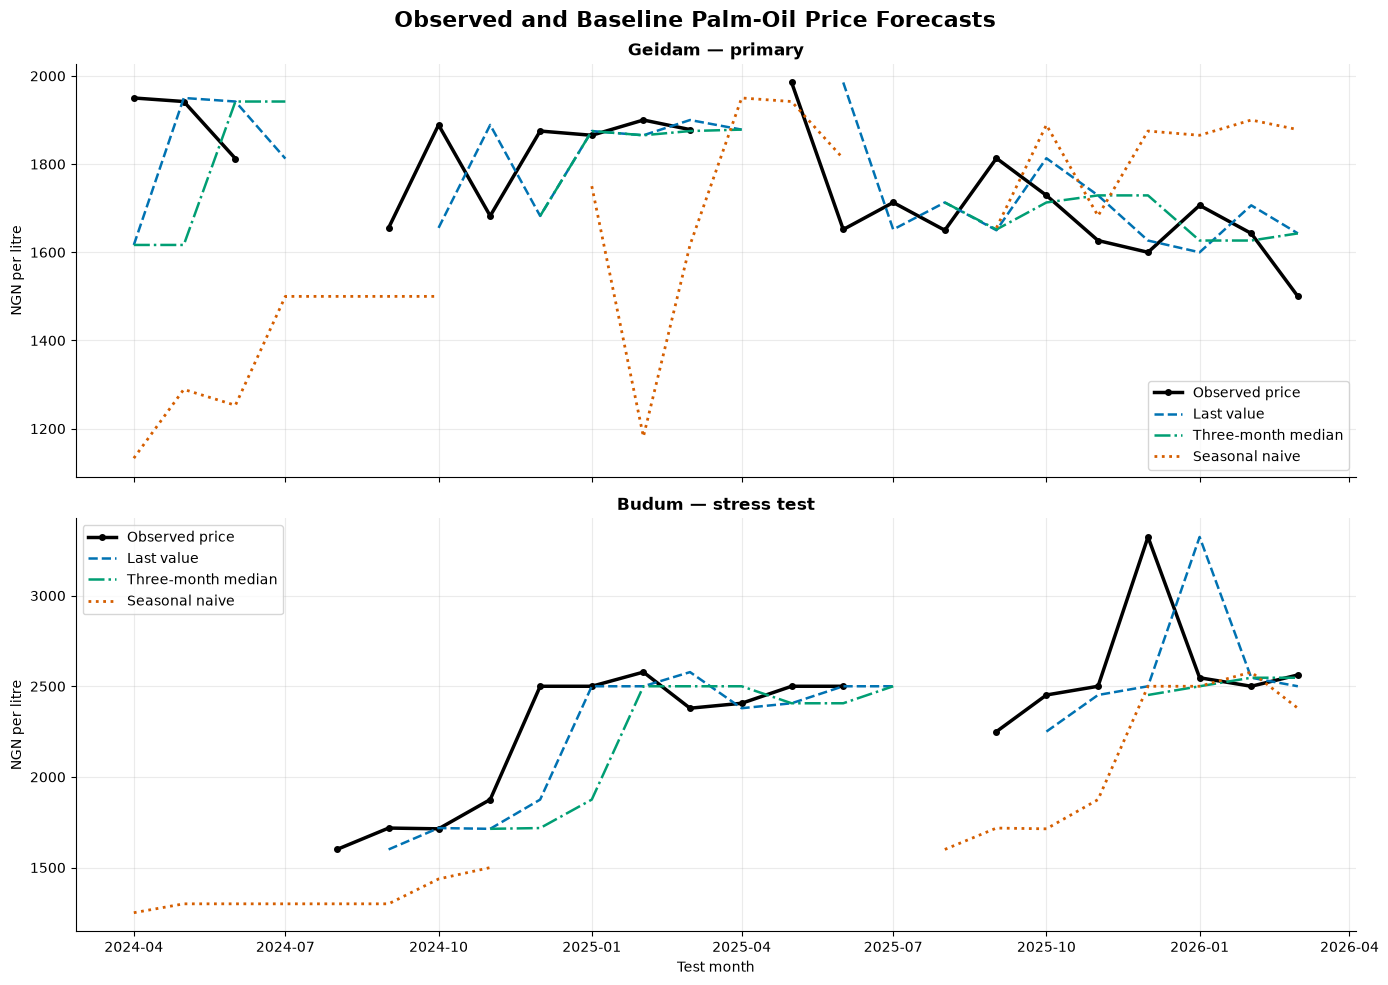

Chart saved to: assets\baseline_forecast_comparison.png


In [8]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 10),
    sharex=True
)

plot_configuration = {
    "price": {
        "label": "Observed price",
        "color": "black",
        "linestyle": "-",
        "linewidth": 2.5
    },
    "last_value_forecast": {
        "label": "Last value",
        "color": "#0072B2",
        "linestyle": "--",
        "linewidth": 1.8
    },
    "rolling_median_3_forecast": {
        "label": "Three-month median",
        "color": "#009E73",
        "linestyle": "-.",
        "linewidth": 1.8
    },
    "seasonal_naive_forecast": {
        "label": "Seasonal naive",
        "color": "#D55E00",
        "linestyle": ":",
        "linewidth": 2
    }
}

series_order = [
    "Geidam — primary",
    "Budum — stress test"
]

for axis, series_name in zip(axes, series_order):
    series = (
        test_predictions[
            test_predictions["series"] == series_name
        ]
        .sort_values("month")
    )

    for column, settings in plot_configuration.items():
        axis.plot(
            series["month"],
            series[column],
            label=settings["label"],
            color=settings["color"],
            linestyle=settings["linestyle"],
            linewidth=settings["linewidth"],
            marker="o" if column == "price" else None,
            markersize=4
        )

    axis.set_title(series_name, fontweight="bold")
    axis.set_ylabel("NGN per litre")
    axis.grid(alpha=0.25)
    axis.legend()
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

axes[-1].set_xlabel("Test month")

fig.suptitle(
    "Observed and Baseline Palm-Oil Price Forecasts",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

assets_directory = project_root / "assets"
assets_directory.mkdir(
    parents=True,
    exist_ok=True
)

baseline_chart_path = (
    assets_directory
    / "baseline_forecast_comparison.png"
)

fig.savefig(
    baseline_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Chart saved to:",
    Path("assets") / baseline_chart_path.name
)

## Last-Value Error Diagnosis

The last-value method is the main reference baseline. Its largest test-period errors are investigated to determine whether they coincide with price-flag transitions, missing periods or abrupt price movements.

This analysis is diagnostic. It does not remove difficult observations from the evaluation.

In [9]:
diagnostic_data = baseline_data.copy()

diagnostic_data["previous_priceflag"] = (
    diagnostic_data
    .groupby("series")["priceflag"]
    .shift(1)
)

diagnostic_data["priceflag_transition"] = (
    diagnostic_data["priceflag"].notna()
    & diagnostic_data["previous_priceflag"].notna()
    & (
        diagnostic_data["priceflag"]
        != diagnostic_data["previous_priceflag"]
    )
)

last_value_errors = diagnostic_data[
    (diagnostic_data["evaluation_period"] == "Test")
    & diagnostic_data["price"].notna()
    & diagnostic_data["last_value_forecast"].notna()
].copy()

last_value_errors["signed_error_ngn"] = (
    last_value_errors["last_value_forecast"]
    - last_value_errors["price"]
)

last_value_errors["absolute_error_ngn"] = (
    last_value_errors["signed_error_ngn"].abs()
)

last_value_errors["absolute_error_pct"] = (
    last_value_errors["absolute_error_ngn"]
    / last_value_errors["price"]
    * 100
)

largest_errors = (
    last_value_errors
    .sort_values(
        ["series", "absolute_error_ngn"],
        ascending=[True, False]
    )
    .groupby("series", sort=False)
    .head(5)
    [
        [
            "series",
            "month",
            "price",
            "last_value_forecast",
            "signed_error_ngn",
            "absolute_error_ngn",
            "absolute_error_pct",
            "previous_priceflag",
            "priceflag",
            "priceflag_transition"
        ]
    ]
)

display(
    largest_errors.style.format({
        "price": "₦{:,.2f}",
        "last_value_forecast": "₦{:,.2f}",
        "signed_error_ngn": "₦{:,.2f}",
        "absolute_error_ngn": "₦{:,.2f}",
        "absolute_error_pct": "{:.2f}%"
    })
)

,series,month,price,last_value_forecast,signed_error_ngn,absolute_error_ngn,absolute_error_pct,previous_priceflag,priceflag,priceflag_transition
226,Budum — stress test,2025-12-01 00:00:00,"₦3,323.53","₦2,500.00",₦-823.53,₦823.53,24.78%,aggregate,aggregate,False
227,Budum — stress test,2026-01-01 00:00:00,"₦2,547.04","₦3,323.53",₦776.49,₦776.49,30.49%,aggregate,aggregate,False
214,Budum — stress test,2024-12-01 00:00:00,"₦2,500.00","₦1,875.00",₦-625.00,₦625.00,25.00%,aggregate,aggregate,False
224,Budum — stress test,2025-10-01 00:00:00,"₦2,451.92","₦2,250.00",₦-201.92,₦201.92,8.24%,aggregate,aggregate,False
217,Budum — stress test,2025-03-01 00:00:00,"₦2,379.03","₦2,578.13",₦199.10,₦199.10,8.37%,aggregate,aggregate,False
102,Geidam — primary,2025-06-01 00:00:00,"₦1,651.72","₦1,985.19",₦333.47,₦333.47,20.19%,aggregate,aggregate,False
88,Geidam — primary,2024-04-01 00:00:00,"₦1,950.00","₦1,616.67",₦-333.33,₦333.33,17.09%,aggregate,aggregate,False
94,Geidam — primary,2024-10-01 00:00:00,"₦1,888.89","₦1,655.40",₦-233.49,₦233.49,12.36%,aggregate,aggregate,False
95,Geidam — primary,2024-11-01 00:00:00,"₦1,682.50","₦1,888.89",₦206.39,₦206.39,12.27%,aggregate,aggregate,False
96,Geidam — primary,2024-12-01 00:00:00,"₦1,875.00","₦1,682.50",₦-192.50,₦192.50,10.27%,aggregate,aggregate,False


## Last-Value Forecast Tolerance

Error metrics are supplemented with tolerance rates showing how frequently the last-value forecast falls within 5%, 10% and 20% of the actual price.

These thresholds are illustrative analytical measures. A real business would need to define acceptable tolerance based on its margins, purchasing volume and risk appetite.

In [10]:
tolerance_records = []

for series_name, series in last_value_errors.groupby(
    "series",
    sort=False
):
    prediction_count = len(series)

    tolerance_records.append({
        "series": series_name,
        "predictions": prediction_count,
        "within_5_pct": (
            series["absolute_error_pct"]
            .le(5)
            .mean()
            * 100
        ),
        "within_10_pct": (
            series["absolute_error_pct"]
            .le(10)
            .mean()
            * 100
        ),
        "within_20_pct": (
            series["absolute_error_pct"]
            .le(20)
            .mean()
            * 100
        ),
        "maximum_error_pct": (
            series["absolute_error_pct"].max()
        )
    })

tolerance_summary = pd.DataFrame(
    tolerance_records
).set_index("series")

display(
    tolerance_summary.style.format({
        "within_5_pct": "{:.2f}%",
        "within_10_pct": "{:.2f}%",
        "within_20_pct": "{:.2f}%",
        "maximum_error_pct": "{:.2f}%"
    })
)

,predictions,within_5_pct,within_10_pct,within_20_pct,maximum_error_pct
series,,,,,
Budum — stress test,16,56.25%,81.25%,81.25%,30.49%
Geidam — primary,19,47.37%,73.68%,94.74%,20.19%


In [11]:
processed_directory = (
    project_root
    / "data"
    / "processed"
)

processed_directory.mkdir(
    parents=True,
    exist_ok=True
)

prediction_export_columns = [
    "series",
    "month",
    "price",
    "priceflag",
    "last_value_forecast",
    "rolling_median_3_forecast",
    "seasonal_naive_forecast"
]

test_predictions[
    prediction_export_columns
].to_csv(
    processed_directory / "baseline_predictions.csv",
    index=False
)

native_metric_results.to_csv(
    processed_directory / "native_baseline_metrics.csv",
    index=False
)

common_metric_results.to_csv(
    processed_directory / "common_target_metrics.csv",
    index=False
)

tolerance_summary.to_csv(
    processed_directory / "last_value_tolerance.csv"
)

generated_files = [
    "baseline_predictions.csv",
    "native_baseline_metrics.csv",
    "common_target_metrics.csv",
    "last_value_tolerance.csv"
]

print("GENERATED LOCAL RESULTS")

for filename in generated_files:
    file_path = processed_directory / filename

    print(
        f"data/processed/{filename}",
        "| exists:",
        file_path.exists(),
        "| bytes:",
        file_path.stat().st_size
    )

GENERATED LOCAL RESULTS
data/processed/baseline_predictions.csv | exists: True | bytes: 3186
data/processed/native_baseline_metrics.csv | exists: True | bytes: 868
data/processed/common_target_metrics.csv | exists: True | bytes: 733
data/processed/last_value_tolerance.csv | exists: True | bytes: 237


## Conclusions

### Evaluation design

The forecasting baselines were evaluated using one-month-ahead walk-forward predictions over the common April 2024 to March 2026 test period.

Geidam contained 21 observed test targets, while Budum contained 18. Missing targets and unavailable forecasts were excluded from error calculations but included when measuring forecast coverage.

### Main baseline result

The last-value method was selected as the reference baseline.

For Geidam, it achieved:

- 19 valid predictions;
- 90.48% forecast coverage;
- 6.93% native-coverage WAPE;
- 5.34% common-target WAPE;
- ₦94.34 common-target MAE;
- approximately zero common-target bias.

Across its 19 valid predictions, 73.68% were within 10% of the actual price and 94.74% were within 20%.

### Budum stress-test result

For Budum, the last-value method produced:

- 16 valid predictions;
- 88.89% forecast coverage;
- 8.47% native-coverage WAPE;
- ₦204.14 native-coverage MAE.

The common-target comparison contained only five Budum months and is therefore insufficient for a strong ranking conclusion.

Across the 16 valid last-value predictions, 81.25% were within 10% of the actual price. However, the maximum error was 30.49%, demonstrating greater observed extreme-error risk than Geidam.

### Baseline comparison

The three-month rolling median sometimes reduced error but produced lower forecast coverage because it requires three consecutive observed months.

The seasonal-naive method substantially under-forecast both markets. Using the price from the same month one year earlier did not adequately represent recent nominal price levels during the test period.

### Failure behaviour

The last-value method performs well when prices change gradually but reacts one month late to sudden movements. A sharp increase creates an under-forecast, while a subsequent reversal can create an over-forecast.

The largest test-period errors did not occur during price-flag transition months. This does not prove that observation methodology has no effect, but it prevents the errors from being attributed directly to an immediate flag change.

### Limitations

- The test samples are small.
- Missing months reduce forecast availability.
- Prices are nominal and have not been adjusted for inflation.
- No external variables such as inflation, exchange rates, fuel costs, weather or insecurity were included.
- The analysis covers two markets and should not be generalised to all Nigerian markets.
- The forecasts represent public market-price estimates, not live supplier quotations.
- WFP price flags were preserved, but their precise production methodology was not independently established.
- No prediction intervals have been produced yet.

### Benchmark for future models

Any advanced statistical or machine-learning model should:

1. be evaluated chronologically;
2. use only information available before each forecast month;
3. be compared with last value on identical target months;
4. improve forecast error without unacceptable loss of coverage;
5. report bias and extreme errors;
6. be tested on both Geidam and Budum;
7. communicate uncertainty rather than presenting forecasts as guarantees.